# Classifying human activities with topological features

This tutorial builds a complete classification pipeline that turns
raw 6-axis motion data into topological features and feeds them to a
support vector machine.

**Dataset.** The [BasicMotions](https://www.timeseriesclassification.com/description.php?Dataset=BasicMotions)
dataset from sktime contains 80 recordings from a wrist-worn sensor
(3-axis accelerometer + 3-axis gyroscope) across four activities:
*badminton*, *running*, *standing*, and *walking*.

**Pipeline.**

1. Load each recording as a 6-channel `TimeSeries`.
2. Windowed Takens embedding produces a sequence of 12-D point clouds
   per recording.
3. Persistent homology (H1) captures loop structure in each window.
4. Stable ranks summarize each persistence barcode as a piecewise
   constant function (PCF).
5. The mean stable rank across windows gives one PCF per recording.
6. An L2 kernel matrix on these PCFs feeds a precomputed-kernel SVC.

## Step 1: Load the dataset

The `load_basic_motions` function provides a canonical train/test
split (40 recordings each, balanced across the four classes).

In [1]:
import numpy as np
from sktime.datasets import load_basic_motions

X_train, y_train = load_basic_motions(split="TRAIN", return_type="numpy3d")
X_test, y_test = load_basic_motions(split="TEST", return_type="numpy3d")

print(f"Train: {X_train.shape[0]} recordings")
print(f"Test:  {X_test.shape[0]} recordings")
print(f"Channels: {X_train.shape[1]} (3-axis accel + 3-axis gyro)")
print(f"Time steps: {X_train.shape[2]}")
print(f"Classes: {sorted(str(c) for c in set(y_train))}")

Train: 40 recordings
Test:  40 recordings
Channels: 6 (3-axis accel + 3-axis gyro)
Time steps: 100
Classes: ['badminton', 'running', 'standing', 'walking']


Let's visualize one recording from each class. Each recording has six
channels: three accelerometer axes and three gyroscope axes.

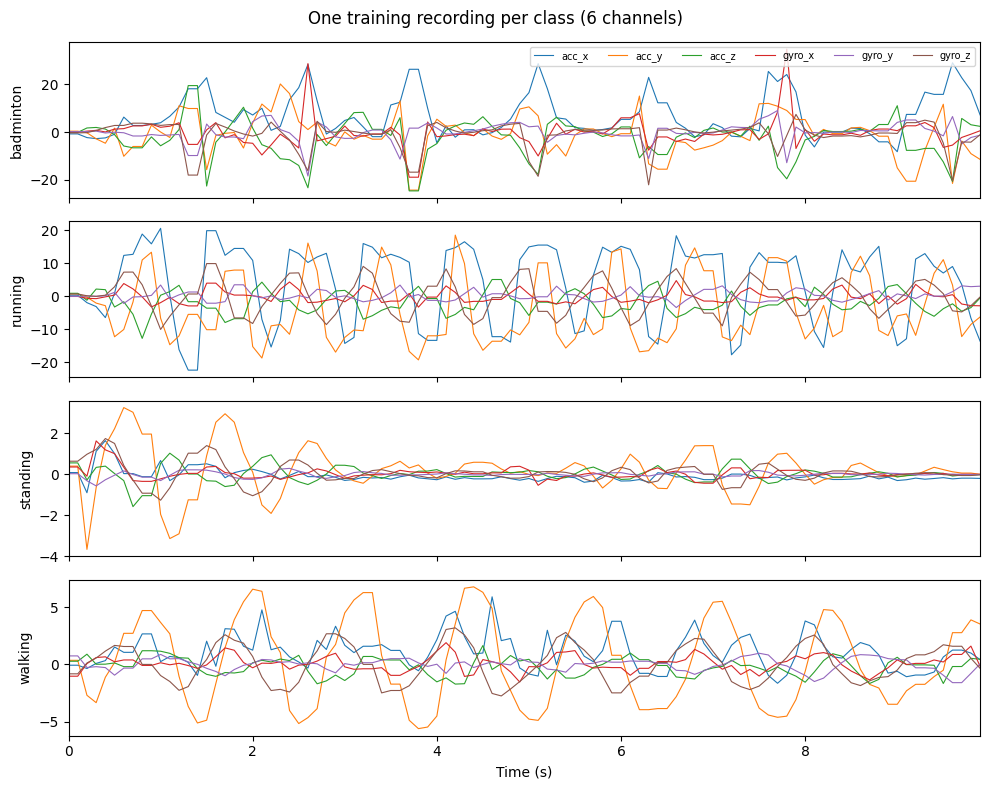

In [2]:
import matplotlib.pyplot as plt

classes = sorted(set(y_train))
fig, axes = plt.subplots(len(classes), 1, figsize=(10, 8), sharex=True)
channel_labels = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
t = np.arange(X_train.shape[2]) * 0.1  # 10 Hz sampling

for ax, cls in zip(axes, classes):
    idx = int(np.where(y_train == cls)[0][0])
    for ch in range(6):
        ax.plot(t, X_train[idx, ch], linewidth=0.8, label=channel_labels[ch])
    ax.set_ylabel(cls)
    ax.set_xlim(t[0], t[-1])

axes[0].legend(fontsize=7, ncol=6, loc="upper right")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("One training recording per class (6 channels)", fontsize=12)
fig.tight_layout()
plt.show()

## Step 2: Convert to multi-channel TimeSeries

Each recording is already in channels-first format
`(n_channels, n_timepoints)`, which is what `TimeSeries` expects.
We build separate tensors for the training and test sets.

In [3]:
import masspcf as mpcf

def make_tensor(X):
    return mpcf.TimeSeriesTensor([
        mpcf.TimeSeries(X[i], start_time=0.0, time_step=0.1)
        for i in range(len(X))
    ])

train_ts = make_tensor(X_train)
test_ts = make_tensor(X_test)

print(f"Train tensor: {train_ts.shape}")
print(f"Test tensor:  {test_ts.shape}")

Train tensor: Shape(40)
Test tensor:  Shape(40)


## Step 3: Windowed Takens embedding

We embed each tensor with dimension 2 and delay 0.3 s (3 time steps).
With 6 channels this produces 12-dimensional delay vectors
(2 delays $\times$ 6 channels).

The `window` parameter splits each recording into overlapping time
windows. Each window yields its own point cloud. We use 3-second
windows with a 1.5-second stride.

In [4]:
embed_kw = dict(dimension=2, delay=0.3, window=3.0, stride=1.5)

train_clouds = mpcf.embed_time_delay(train_ts, **embed_kw)
test_clouds = mpcf.embed_time_delay(test_ts, **embed_kw)
pts0 = np.asarray(train_clouds[0, 0])

print(f"Train clouds: {train_clouds.shape}")
print(f"Test clouds:  {test_clouds.shape}")
print(f"Points per window: {pts0.shape[0]}, dimension: {pts0.shape[1]}")

Train clouds: Shape(40, 6)
Test clouds:  Shape(40, 6)
Points per window: 22, dimension: 12


Let's project one window's 12-D point cloud down to 3-D (using the first
three accelerometer delay coordinates) for each class, to get a visual
sense of how the geometry differs.

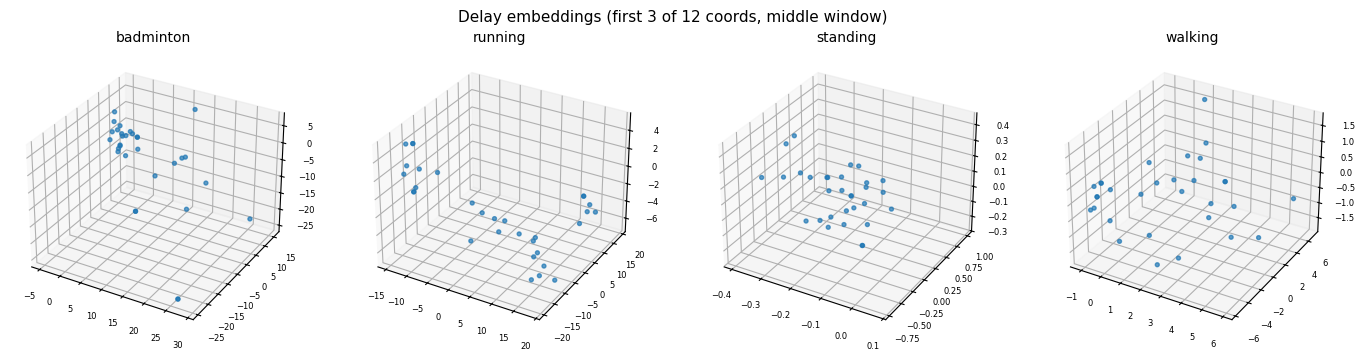

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5),
                         subplot_kw={"projection": "3d"})

mid = train_clouds.shape[1] // 2
for ax, cls in zip(axes, classes):
    idx = int(np.where(y_train == cls)[0][0])
    pts = np.asarray(train_clouds[idx, mid])[:, :3]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=8, alpha=0.7)
    ax.set_title(cls, fontsize=10)
    ax.tick_params(labelsize=6)

fig.suptitle("Delay embeddings (first 3 of 12 coords, middle window)",
             fontsize=11)
fig.tight_layout()
plt.show()

## Step 4: Persistent homology and stable ranks

We compute persistent homology (up to H1) on the entire
`PointCloudTensor` at once -- every window of every recording in a
single call. The barcodes are then converted to **stable ranks**,
which count at each threshold $t$ the number of bars with length
exceeding $t$.

We extract the H1 slice and average across windows with `mpcf.mean`
to obtain one PCF per recording.

In [6]:
from masspcf.persistence import (
    barcode_to_stable_rank,
    compute_persistent_homology,
)

def build_features(clouds):
    """Barcodes -> stable ranks -> mean H1 per recording."""
    barcodes = compute_persistent_homology(clouds, max_dim=1)
    sranks = barcode_to_stable_rank(barcodes)
    return mpcf.mean(sranks[:, :, 1], dim=1)

train_features = build_features(train_clouds)
test_features = build_features(test_clouds)

print(f"Train features: {train_features.shape}")
print(f"Test features:  {test_features.shape}")

Train features: Shape(40)
Test features:  Shape(40)


Let's plot the mean H1 stable rank for one training recording from each
class. Activities with more periodic or looping motion produce higher,
wider stable ranks.

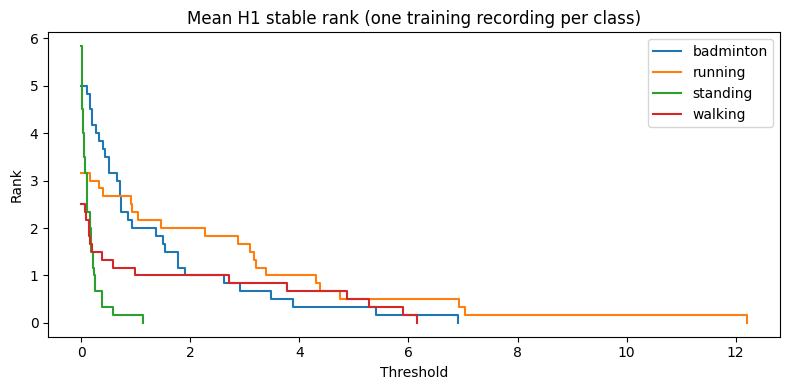

In [7]:
from masspcf.plotting import plot as plotpcf

fig, ax = plt.subplots(figsize=(8, 4))
colors = {"badminton": "C0", "running": "C1", "standing": "C2", "walking": "C3"}

for cls in classes:
    idx = int(np.where(y_train == cls)[0][0])
    plotpcf(train_features[idx], ax=ax, color=colors[cls], label=cls, linewidth=1.5)

ax.set_title("Mean H1 stable rank (one training recording per class)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Rank")
ax.legend()
fig.tight_layout()
plt.show()

## Step 5: L2 kernel matrix

The `l2_kernel` function computes the pairwise inner product between
stable-rank PCFs:

$$
K_{ij} = \int_0^\infty f_i(t)\, f_j(t)\, dt
$$

With one argument it returns the symmetric self-kernel; with two
arguments it returns the cross-kernel. We need both: the training
kernel for fitting the SVM, and the test-vs-train kernel for
prediction.

K_train: (40, 40)
K_test:  (40, 40)


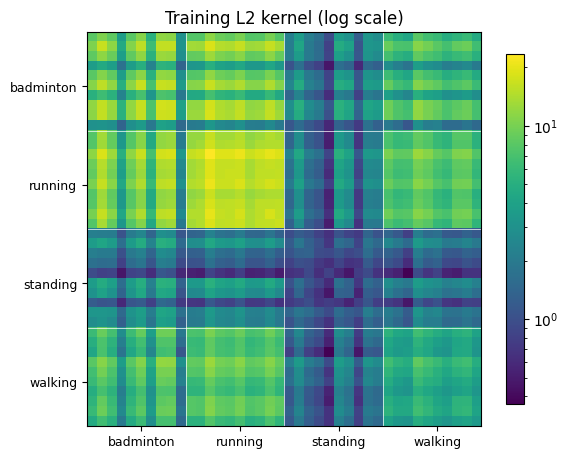

In [8]:
from matplotlib.colors import LogNorm

K_train = mpcf.l2_kernel(train_features).to_dense()
K_test = np.asarray(mpcf.l2_kernel(test_features, train_features))

print(f"K_train: {K_train.shape}")
print(f"K_test:  {K_test.shape}")

# Visualize the training kernel sorted by class
sort_idx = np.argsort(y_train)
K_sorted = K_train[np.ix_(sort_idx, sort_idx)]
y_sorted = y_train[sort_idx]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(K_sorted, cmap="viridis",
               norm=LogNorm(vmin=max(K_sorted.min(), 1e-2)))

counts = [np.sum(y_sorted == cls) for cls in classes]
cumulative = np.cumsum([0] + counts)
centers = [(cumulative[i] + cumulative[i + 1]) / 2 for i in range(len(classes))]
boundaries = cumulative[1:-1] - 0.5

for b in boundaries:
    ax.axhline(b, color="white", linewidth=0.5)
    ax.axvline(b, color="white", linewidth=0.5)

ax.set_xticks(centers)
ax.set_xticklabels(classes, fontsize=9)
ax.set_yticks(centers)
ax.set_yticklabels(classes, fontsize=9)
ax.set_title("Training L2 kernel (log scale)")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

## Step 6: Classification with SVC

We fit a precomputed-kernel SVM on the training kernel and evaluate
on the held-out test set.

In [9]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC

clf = SVC(kernel="precomputed")
clf.fit(K_train, y_train)
preds = clf.predict(K_test)

print(classification_report(y_test, preds))
print(f"Test accuracy: {accuracy_score(y_test, preds):.0%}")

              precision    recall  f1-score   support

   badminton       0.71      0.50      0.59        10
     running       1.00      1.00      1.00        10
    standing       0.83      1.00      0.91        10
     walking       0.73      0.80      0.76        10

    accuracy                           0.82        40
   macro avg       0.82      0.82      0.81        40
weighted avg       0.82      0.82      0.81        40

Test accuracy: 82%


Let's also look at the confusion matrix to see which activities are
easiest or hardest to distinguish topologically.

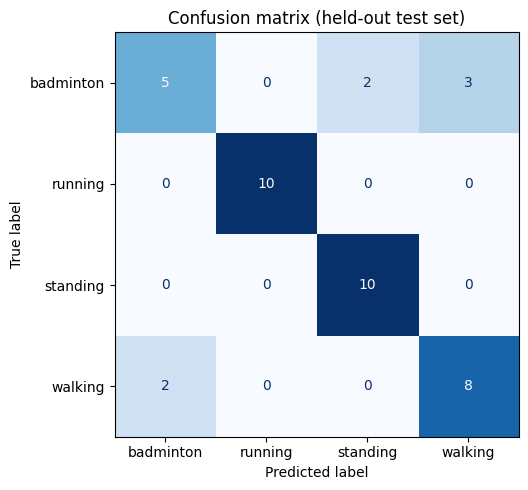

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds, labels=classes)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (held-out test set)")
fig.tight_layout()
plt.show()

## Summary

This tutorial demonstrated a full topological machine learning pipeline
with a proper train/test split:

| Step | Tool | Input → Output |
|------|------|----------------|
| Raw data | `sktime.load_basic_motions` | → 40 train + 40 test recordings |
| Time series | `mpcf.TimeSeriesTensor` | → shape `(40,)` each |
| Embedding | `mpcf.embed_time_delay` | → `PointCloudTensor` shape `(40, 6)` |
| Topology | `compute_persistent_homology` | → `BarcodeTensor` shape `(40, 6, 2)` |
| Features | `barcode_to_stable_rank` + `mpcf.mean` | → `PcfTensor` shape `(40,)` |
| Kernel | `mpcf.l2_kernel` | → train 40 × 40, test 40 × 40 |
| Classifier | `sklearn.svm.SVC(kernel="precomputed")` | → test predictions |

Every computation step operates on entire tensors -- no Python loops
over individual recordings. The `embed_time_delay`,
`compute_persistent_homology`, and `barcode_to_stable_rank` functions
propagate through the tensor dimensions automatically.

The key insight is that masspcf's native L2 kernel on stable ranks
lets us go from raw sensor data to a precomputed kernel SVM without
ever discretizing the topological features into fixed-length vectors.
The stable rank is a *function-valued* feature, and `l2_kernel`
computes the exact integral inner product between these functions.

## Using sklearn pipelines

The `masspcf.sklearn` module provides transformer wrappers for each
step, so the entire pipeline above can be expressed as a standard
sklearn `Pipeline`. This makes it compatible with `GridSearchCV`,
`cross_val_score`, and other sklearn utilities.

In [ ]:
from sklearn.pipeline import Pipeline
from masspcf.sklearn import (
    TimeDelayEmbedding,
    PersistentHomology,
    StableRank,
    Mean,
    PcfKernelTransformer,
)

pipe = Pipeline([
    ("embed", TimeDelayEmbedding(
        dimension=2, delay=0.3, time_step=0.1, window=3.0, stride=1.5)),
    ("ph", PersistentHomology(max_dim=1)),
    ("sr", StableRank(dim=1)),
    ("mean", Mean()),
    ("kernel", PcfKernelTransformer()),
    ("svc", SVC(kernel="precomputed")),
])

pipe.fit(X_train, y_train)
print(f"Pipeline test accuracy: {pipe.score(X_test, y_test):.0%}")

### Tuning embedding parameters with GridSearchCV

Because each transformer exposes its parameters to sklearn, we can
use `GridSearchCV` to search over embedding settings. The pipeline
parameter names follow the `stepname__param` convention.

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "embed__dimension": [2, 3],
    "embed__delay": [0.2, 0.3, 0.5],
    "embed__window": [2.0, 3.0, 5.0],
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring="accuracy")
grid.fit(X_train, y_train)

print(f"Best CV accuracy: {grid.best_score_:.0%}")
print(f"Best parameters:  {grid.best_params_}")
print(f"Test accuracy:    {grid.score(X_test, y_test):.0%}")

Best CV accuracy: 95%
Best parameters:  {'embed__delay': 0.5, 'embed__dimension': 3, 'embed__window': 3.0}
Test accuracy:    90%
